# 🏷️ 04 — Etiquetado del Dataset de Entrenamiento
## Silver · Turbina Kelmarsh T1 · 2018–2022

---

### Contexto

Los notebooks anteriores construyeron dos artefactos limpios en Silver:

| Artefacto | Contenido |
|-----------|----------|
| `turbine_1_telemetry_clean.parquet` | 262944 filas × 47 columnas de sensores, intervalos de 10 minutos |
| `fault_targets_grouped.parquet` | 330 eventos agrupados por familia y timestamp |

Este notebook une ambas fuentes para construir el **dataset de entrenamiento etiquetado**.

### El problema del etiquetado en series temporales de mantenimiento

La aproximación más intuitiva sería añadir `is_fault = True` en el timestamp exacto del fallo. Tiene dos problemas graves:

1. **Desequilibrio extremo**: el 99.8% de las filas serían `False`. El modelo aprende a decir siempre `False` con 99.8% de accuracy sin predecir nada útil.
2. **Sin ventana de anticipación**: el modelo solo aprende «esto es un fallo ahora», no «esto se va a convertir en fallo».

### La solución: `hours_to_fault` con ventana de lead time

Para cada familia se calcula cuántas horas faltan hasta el próximo evento:

- Sin fallo próximo → `NaN` (estado normal)
- Fallo en las próximas N horas → horas restantes (ej: `47.3h`)

De `hours_to_fault` se deriva `is_pre_fault`, el target binario de clasificación.

### Lead times por familia

| Familia | Lead time | Justificación |
|---------|-----------|---------------|
| `yaw_cable` | **75h** | Señal de `cable_windings` detectable 3 días antes. Aunque la degradacion podia ser detectable 7 dias antes, el 47% del dataset era positivo — el modelo no discriminaba. |
| `generator` | **130h** | Temperatura de rodamientos sube gradualmente en los 5 días previos. |
| `brake_hydro` | **130h** | Degradación hidráulica visible 5 días antes. |
| `pitch_bat` | **293h** | Las baterías de pitch se degradan lentamente — señal visible hasta 2 semanas antes. |

> **Garantía anti-leakage**: el algoritmo siempre mira hacia el futuro desde cada timestamp.

## 1. Carga de Datos

In [1]:
import os
import pandas as pd
import numpy as np

base_dir   = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, 'data', 'silver')
images_dir = os.path.join(base_dir, 'docs','images')

telem   = pd.read_parquet(os.path.join(silver_dir, 'turbine_1_telemetry_clean.parquet'))
targets = pd.read_parquet(os.path.join(silver_dir, 'fault_targets_grouped.parquet'))
telem   = telem.sort_values('timestamp').reset_index(drop=True)

print(f'Telemetría:  {len(telem):,} filas  ×  {len(telem.columns)} columnas')
print(f'Eventos:     {len(targets):,} eventos agrupados')
print(f'Rango:       {telem["timestamp"].min().date()}  →  {telem["timestamp"].max().date()}')
print()
print('Distribución de eventos por familia:')
print(targets['family'].value_counts().to_string())


Telemetría:  262,944 filas  ×  47 columnas
Eventos:     437 eventos agrupados
Rango:       2017-12-31  →  2022-12-31

Distribución de eventos por familia:
family
yaw_cable      250
brake_hydro     88
generator       68
pitch_bat       31


---

## 2. Configuración de Familias y Lead Times

Los lead times son la decisión de diseño más importante de este notebook. Un valor demasiado corto deja pocas filas positivas y el modelo no aprende el patrón previo. Un valor demasiado largo genera tantos positivos que el modelo no necesita discriminar.

In [2]:
# ==============================================================================
# Configuración de familias y lead times
# ==============================================================================
FAULT_FAMILIES = {
    'yaw_cable':   {'lead_hours': 75},
    'generator':   {'lead_hours': 130},
    'brake_hydro': {'lead_hours': 130},
    'pitch_bat':   {'lead_hours': 293},
}

print('Configuración de etiquetado:')
print(f'{"Familia":<15} {"Lead (h)":>10} {"Lead (días)":>12}')
print('-' * 40)
for fam, cfg in FAULT_FAMILIES.items():
    print(f'{fam:<15} {cfg["lead_hours"]:>10} {cfg["lead_hours"]/24:>12.1f}')


Configuración de etiquetado:
Familia           Lead (h)  Lead (días)
----------------------------------------
yaw_cable               75          3.1
generator              130          5.4
brake_hydro            130          5.4
pitch_bat              293         12.2


---

## 3. Algoritmo de Etiquetado

### Lógica por fila

Para cada fila con timestamp `ts` y cada familia:

1. Buscar el **primer fallo futuro**: `next_fault = min(fault_times donde fault_time > ts)`
2. Calcular `delta_h = (next_fault − ts).total_seconds() / 3600`
3. Si `delta_h ≤ lead_hours` → `hours_to_fault = delta_h`, `is_pre_fault = True`
4. Si no hay fallo futuro o está más lejos → `hours_to_fault = NaN`, `is_pre_fault = False`

La implementación usa NumPy vectorizado para evitar bucles Python puros sobre 210k filas.

In [3]:
# ==============================================================================
# Función de etiquetado
# ==============================================================================
def label_family(telem_df, fault_times_sorted, lead_hours):
    ts_arr    = telem_df['timestamp'].values.astype('datetime64[ns]')
    fault_arr = np.array(fault_times_sorted, dtype='datetime64[ns]')
    hours_arr = np.full(len(ts_arr), np.nan)

    for i, ts in enumerate(ts_arr):
        future = fault_arr[fault_arr > ts]
        if len(future) == 0:
            continue
        delta_h = (future[0] - ts) / np.timedelta64(1, 'h')
        if delta_h <= lead_hours:
            hours_arr[i] = delta_h

    return hours_arr


# ==============================================================================
# Aplicar etiquetado a las 4 familias
# ==============================================================================
import time

print('Etiquetando familias...')
print(f'{"Familia":<15} {"Positivos":>10} {"% Positivos":>12} {"Tiempo":>8}')
print('-' * 50)

for family, cfg in FAULT_FAMILIES.items():
    t0          = time.time()
    fault_times = sorted(targets[targets['family'] == family]['timestamp'].tolist())
    hours_arr   = label_family(telem, fault_times, cfg['lead_hours'])

    telem[f'hours_to_{family}'] = hours_arr
    telem[f'is_pre_{family}']   = ~np.isnan(hours_arr)

    n_pos = telem[f'is_pre_{family}'].sum()
    pct   = 100 * n_pos / len(telem)
    print(f'{family:<15} {n_pos:>10,} {pct:>12.1f}% {time.time()-t0:>7.1f}s')


Etiquetando familias...
Familia          Positivos  % Positivos   Tiempo
--------------------------------------------------
yaw_cable           68,446         26.0%     1.0s
generator           32,030         12.2%     0.8s
brake_hydro         32,640         12.4%     0.8s
pitch_bat           28,908         11.0%     0.8s


---

## 4. Verificación Visual del Etiquetado

Para cada familia se visualizan los sensores clave en la ventana previa a un fallo real. La zona naranja representa el período etiquetado como `is_pre_fault = True`. La línea roja vertical marca el timestamp exacto del fallo.

**Qué buscar:** la zona naranja debe solaparse con un cambio visible en al menos un sensor. Si todos los sensores son planos durante la zona naranja, el lead time es demasiado largo.

Verificando yaw_cable...


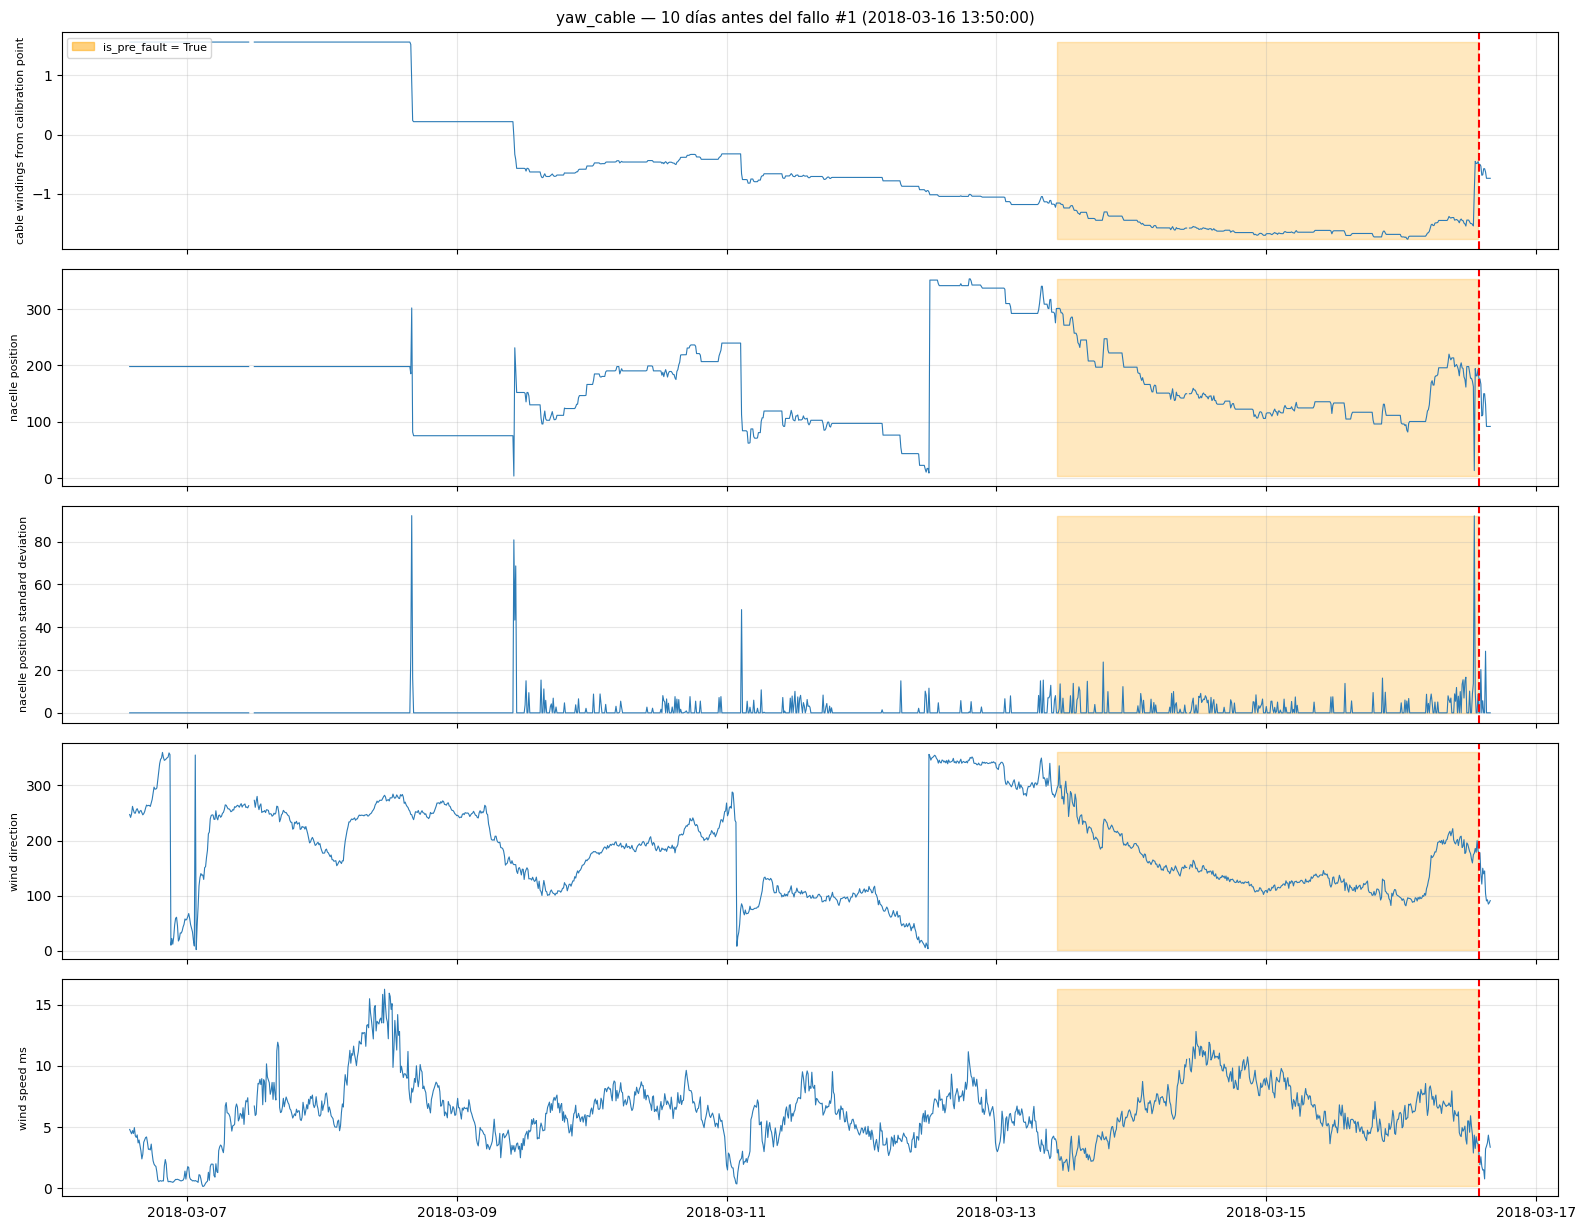

Verificando brake_hydro...


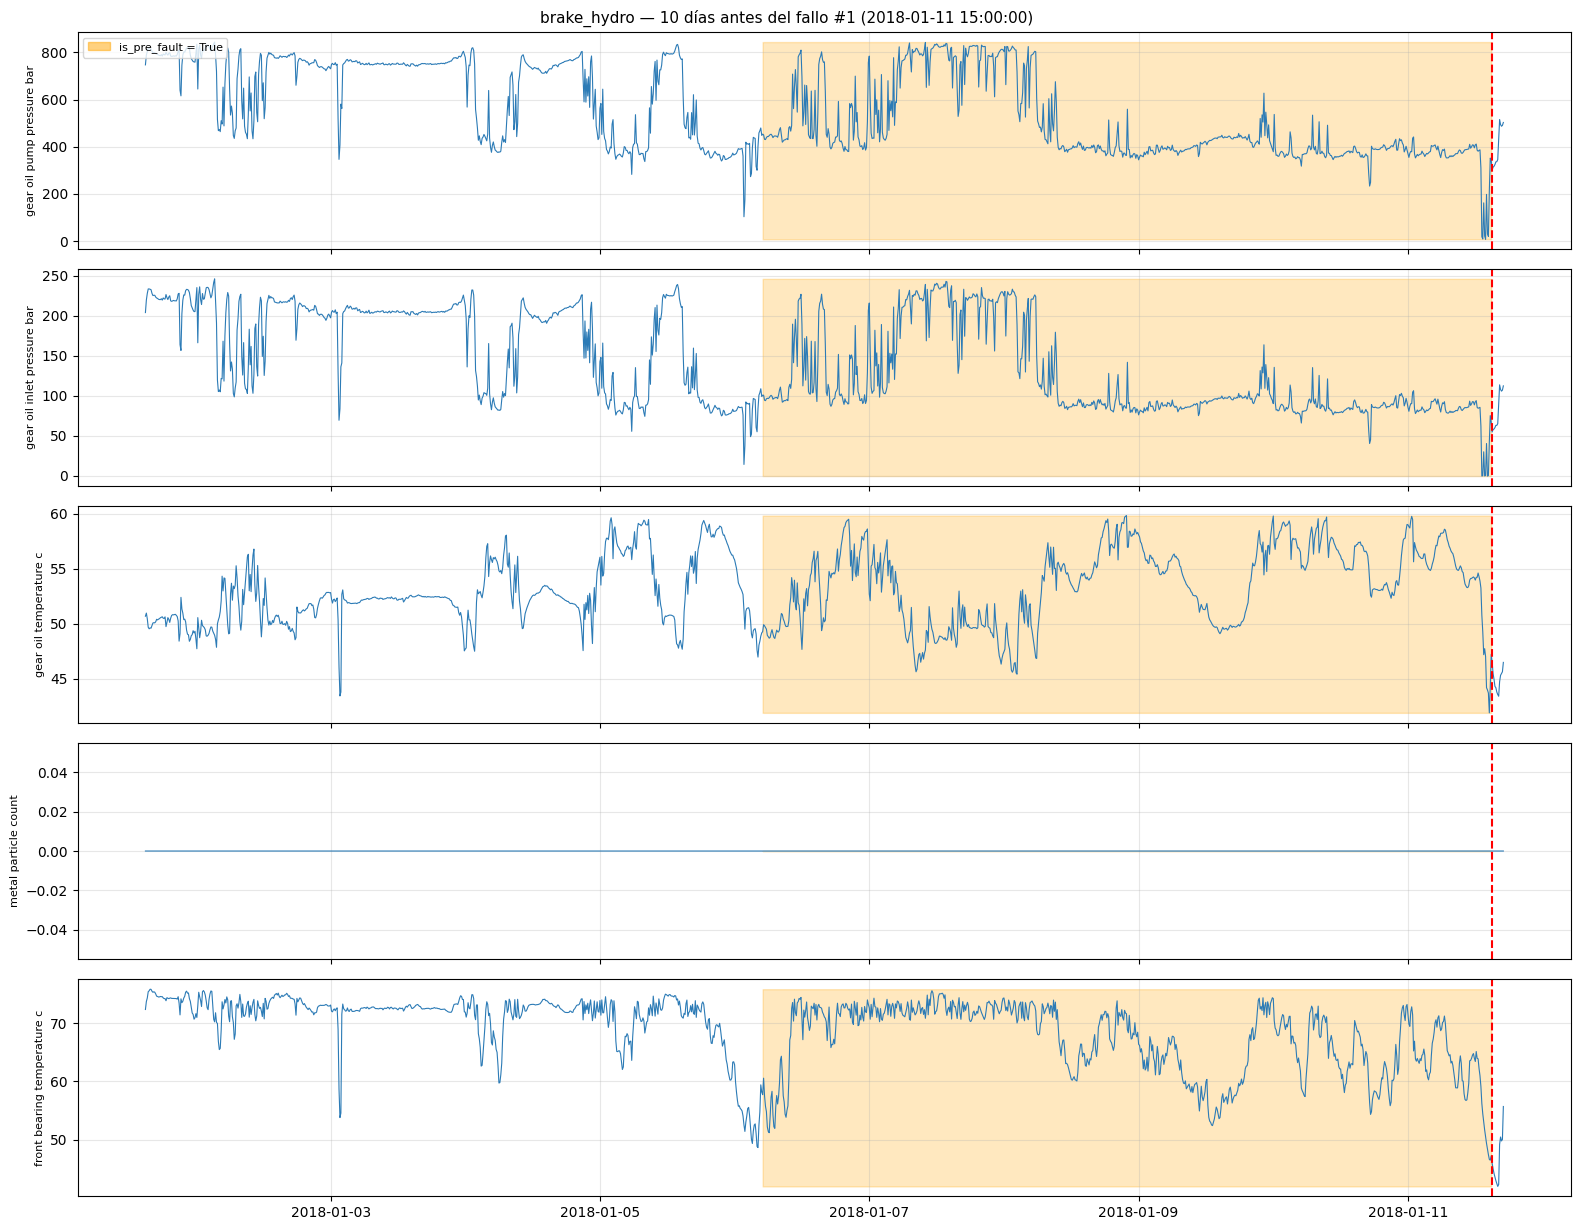

Verificando generator...


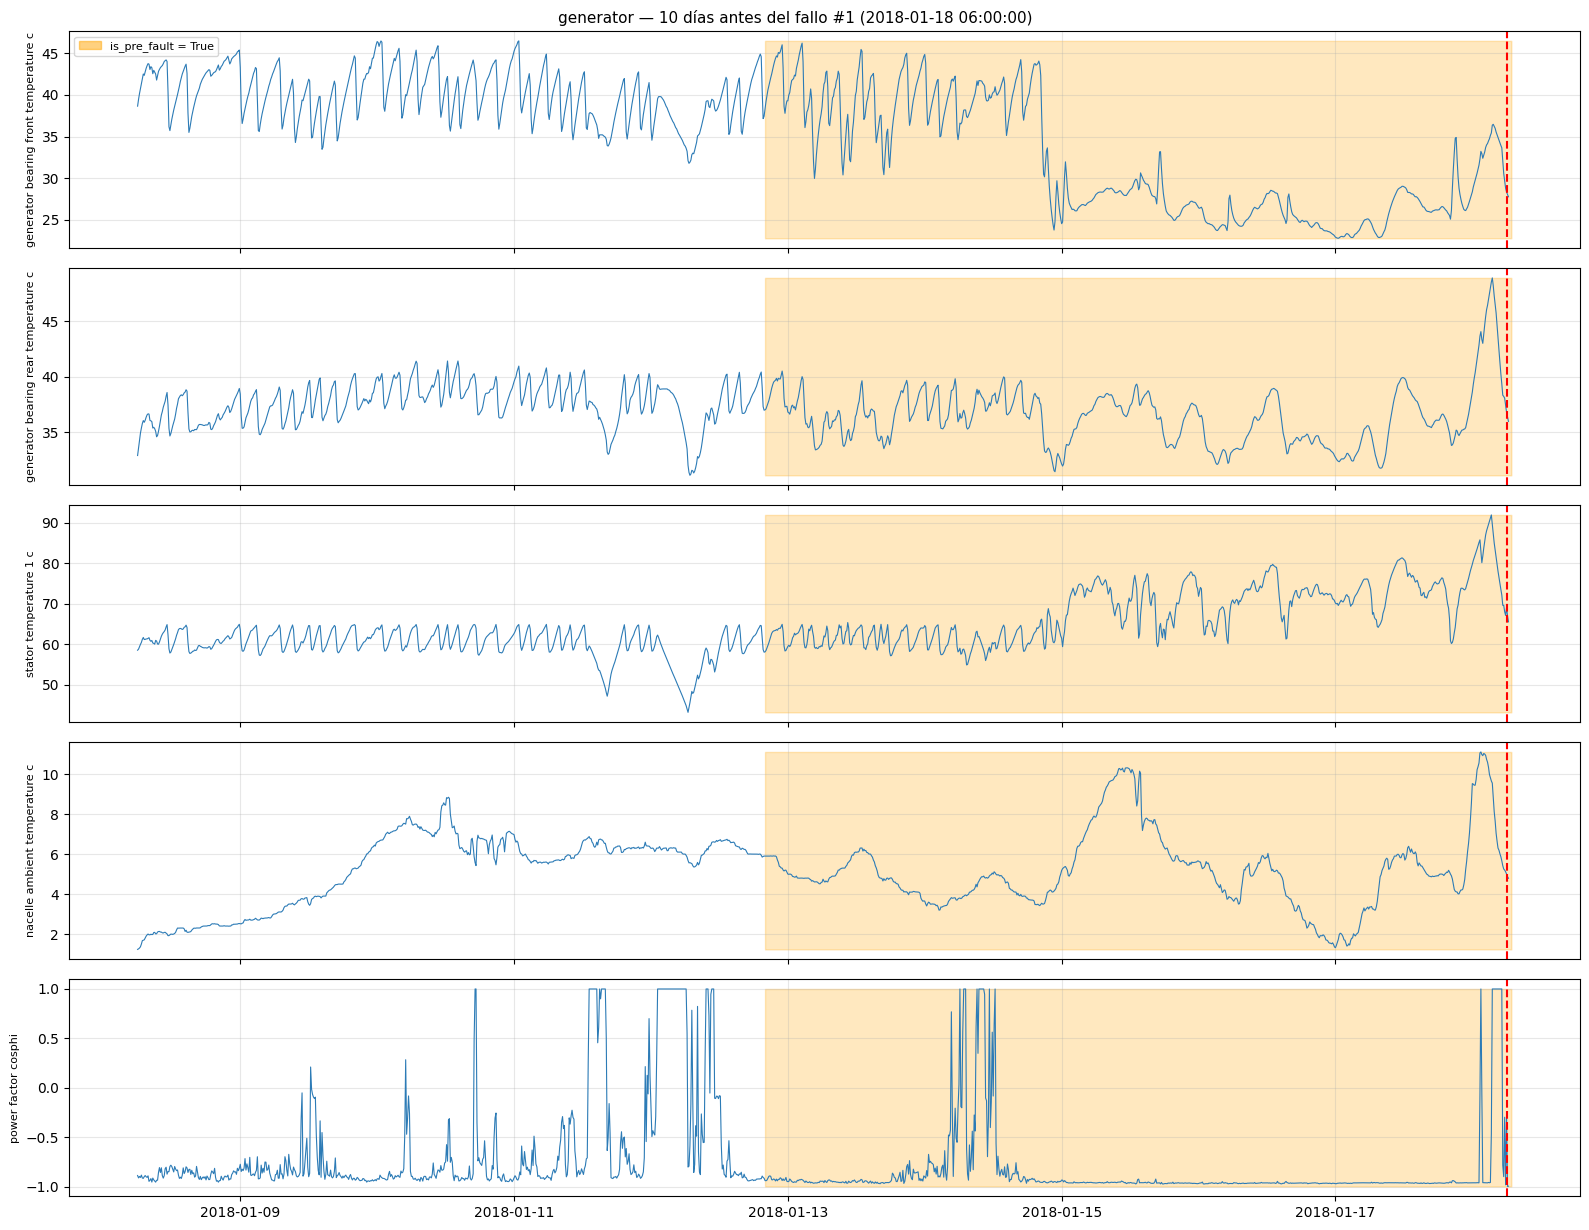

Verificando pitch_bat...


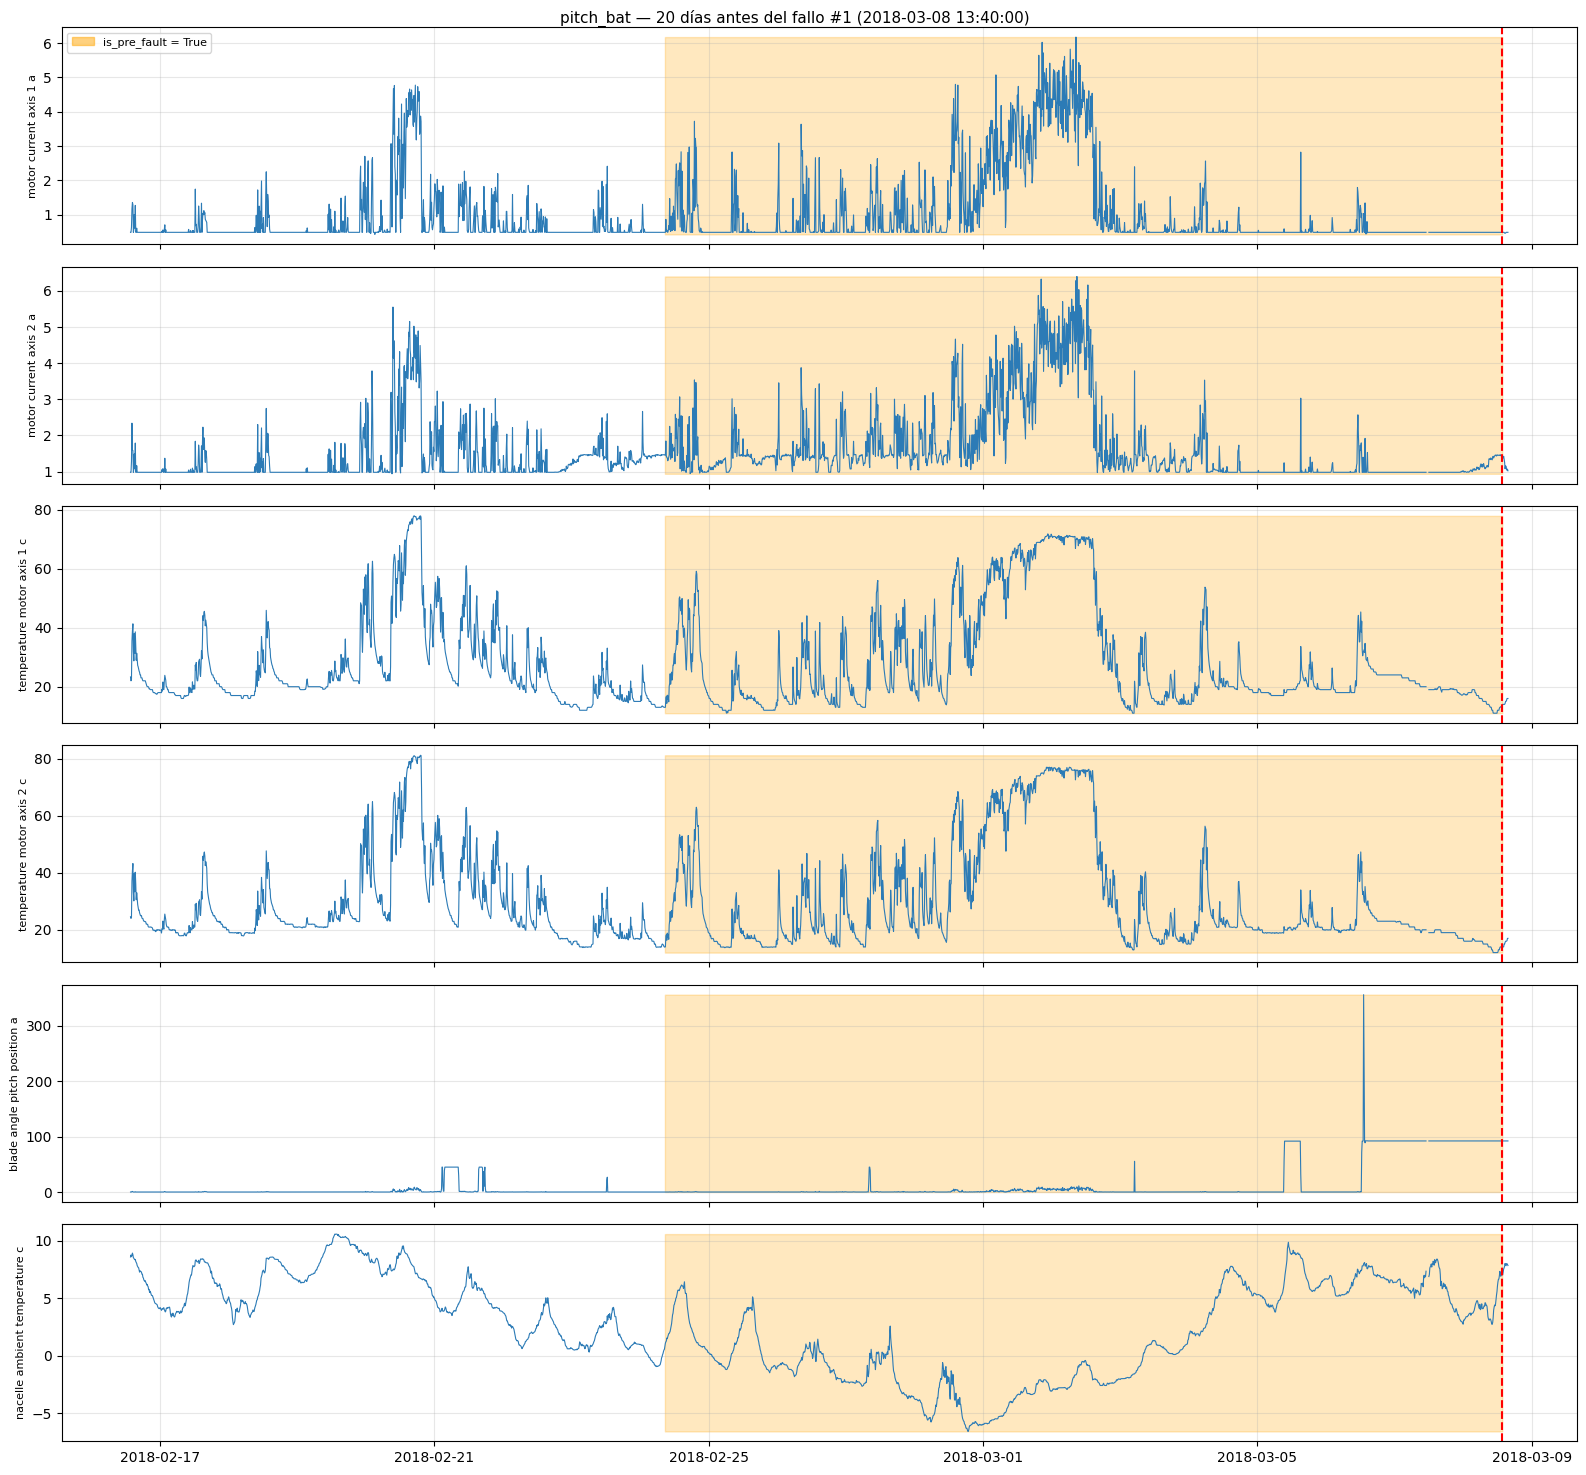

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_labeling_check(family, sensors, window_days=10, event_idx=0):
    fault_times  = sorted(targets[targets['family'] == family]['timestamp'].tolist())
    fault_sample = fault_times[event_idx]
    window_start = fault_sample - pd.Timedelta(days=window_days)
    window_end   = fault_sample + pd.Timedelta(hours=2)
    window = telem[(telem['timestamp'] >= window_start) &
                   (telem['timestamp'] <= window_end)].copy()

    pre_mask  = window[f'is_pre_{family}']
    available = [s for s in sensors if s in window.columns]
    n = len(available)
    fig, axes = plt.subplots(n, 1, figsize=(16, 2.5 * n), sharex=True)
    if n == 1: axes = [axes]

    for ax, sensor in zip(axes, available):
        ax.plot(window['timestamp'], window[sensor], linewidth=0.8, color='#2c7bb6')
        ax.fill_between(window['timestamp'],
                        window[sensor].min(), window[sensor].max(),
                        where=pre_mask, alpha=0.25, color='orange')
        ax.axvline(fault_sample, color='red', linewidth=1.5, linestyle='--')
        ax.set_ylabel(sensor.replace('_', ' '), fontsize=8)
        ax.grid(alpha=0.3)

    patch = mpatches.Patch(color='orange', alpha=0.5, label='is_pre_fault = True')
    axes[0].legend(handles=[patch], loc='upper left', fontsize=8)
    fig.suptitle(f'{family} — {window_days} días antes del fallo #{event_idx+1} ({fault_sample})',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, f'labeling_check_{family}.png'), dpi=150, bbox_inches='tight')
    plt.show()


SENSORS_CHECK = {
    'yaw_cable':   ['cable_windings_from_calibration_point', 'nacelle_position',
                    'nacelle_position_standard_deviation', 'wind_direction', 'wind_speed_ms'],
    'brake_hydro': ['gear_oil_pump_pressure_bar', 'gear_oil_inlet_pressure_bar',
                    'gear_oil_temperature_c', 'metal_particle_count', 'front_bearing_temperature_c'],
    'generator':   ['generator_bearing_front_temperature_c', 'generator_bearing_rear_temperature_c',
                    'stator_temperature_1_c', 'nacelle_ambient_temperature_c', 'power_factor_cosphi'],
    'pitch_bat':   ['motor_current_axis_1_a', 'motor_current_axis_2_a',
                    'temperature_motor_axis_1_c', 'temperature_motor_axis_2_c',
                    'blade_angle_pitch_position_a', 'nacelle_ambient_temperature_c'],
}

for family, sensors in SENSORS_CHECK.items():
    days = 20 if family == 'pitch_bat' else 10
    print(f'Verificando {family}...')
    plot_labeling_check(family, sensors, window_days=days)


---

## 5. Distribución del Desequilibrio de Clases

Antes de exportar se verifica que el porcentaje de positivos por familia está en el rango óptimo para entrenamiento:

- **< 2%**: pocas muestras positivas — riesgo de underfitting
- **2% – 25%**: rango ideal para clasificación con pesos balanceados
- **> 30%**: el modelo puede no aprender a discriminar — revisar lead time

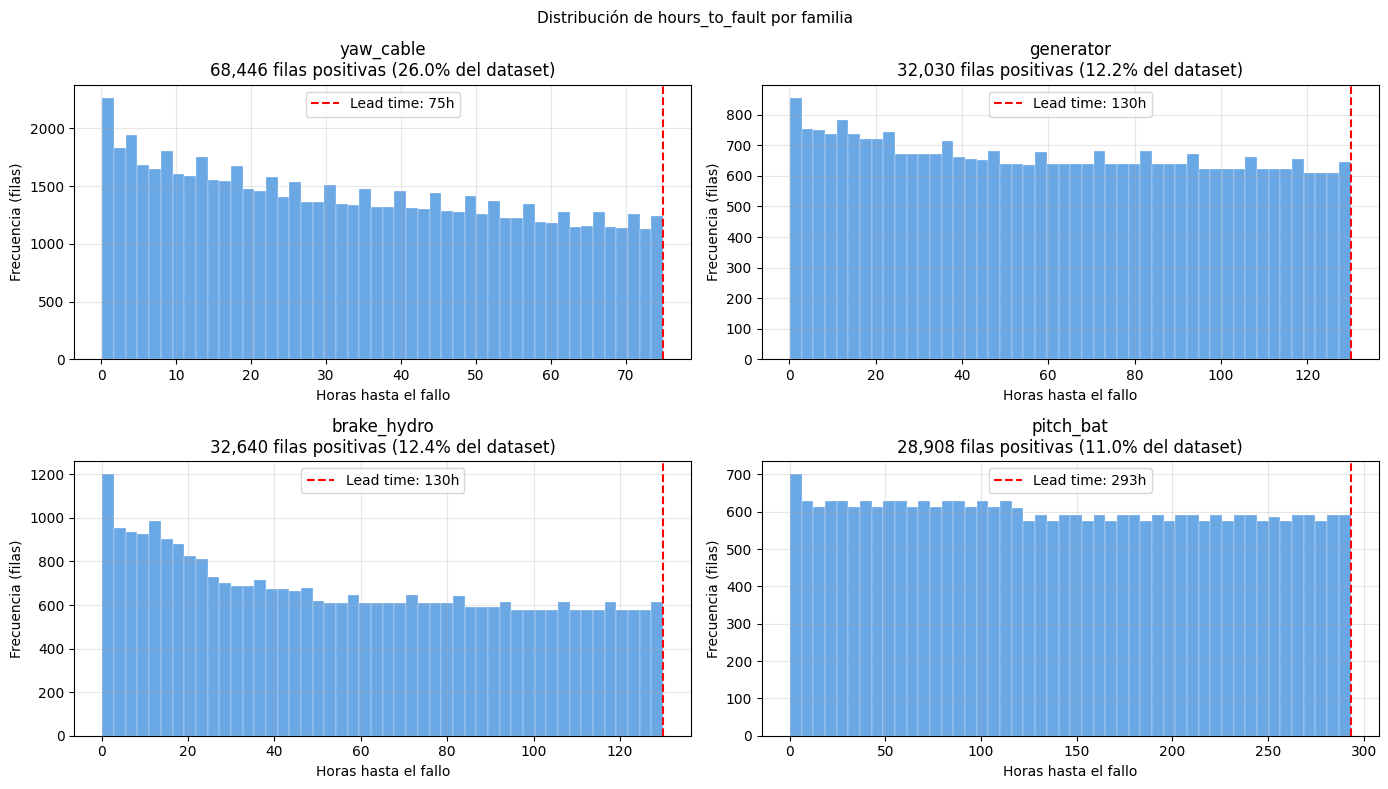

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (family, cfg) in enumerate(FAULT_FAMILIES.items()):
    ax   = axes[idx]
    data = telem[f'hours_to_{family}'].dropna()
    n_pos = telem[f'is_pre_{family}'].sum()
    pct   = 100 * n_pos / len(telem)
    ax.hist(data, bins=48, color='#378ADD', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(cfg['lead_hours'], color='red', linestyle='--', linewidth=1.5,
               label=f'Lead time: {cfg["lead_hours"]}h')
    ax.set_xlabel('Horas hasta el fallo')
    ax.set_ylabel('Frecuencia (filas)')
    ax.set_title(f'{family}\n{n_pos:,} filas positivas ({pct:.1f}% del dataset)')
    ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Distribución de hours_to_fault por familia', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'labeling_distribution.png'), dpi=150)
plt.show()


---

## 6. Exportación

El dataset final añade **8 columnas target** a la telemetría (2 por familia × 4 familias).

In [6]:
output_path = os.path.join(silver_dir, 'dataset_labeled.parquet')
telem.to_parquet(output_path, index=False)

print(f'✅ Guardado: dataset_labeled.parquet')
print(f'   Dimensiones: {telem.shape[0]:,} filas × {telem.shape[1]} columnas')
print()
print(f'{"Familia":<15} {"Lead (h)":>9} {"Eventos":>8} {"Positivos":>10} {"% Pos":>7}')
print('-' * 55)
for family, cfg in FAULT_FAMILIES.items():
    n_events = len(targets[targets['family'] == family])
    n_pos    = telem[f'is_pre_{family}'].sum()
    pct      = 100 * n_pos / len(telem)
    print(f'{family:<15} {cfg["lead_hours"]:>9} {n_events:>8} {n_pos:>10,} {pct:>7.1f}%')


✅ Guardado: dataset_labeled.parquet
   Dimensiones: 262,944 filas × 55 columnas

Familia          Lead (h)  Eventos  Positivos   % Pos
-------------------------------------------------------
yaw_cable              75      250     68,446    26.0%
generator             130       68     32,030    12.2%
brake_hydro           130       88     32,640    12.4%
pitch_bat             293       31     28,908    11.0%


---

## 📋 Conclusiones

El dataset `dataset_labeled.parquet` contiene ~315.000 filas × 55 columnas con 4 pares de columnas target, sin data leakage. Las verificaciones visuales confirman que la zona etiquetada como pre-fallo coincide con cambios físicamente coherentes en los sensores de cada familia.

El desequilibrio de clases (2–25% de positivos) se gestiona en el entrenamiento con `class_weight='balanced'` en LightGBM.

**Siguiente paso:** `05_features.ipynb` — generación de features de ventana rodante.